In [17]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [18]:
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'anemometers_160226.csv'

ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

In [19]:
df = pd.read_csv(ground_data_path, sep=",")

In [20]:
df

,1 (chico),2 (grande)
0,0.1,1.5
1,0.3,1.3
2,0.3,1.4
3,0.2,1.3
4,0.1,1.2
5,0.0,1.4
6,0.2,0.8
7,0.3,0.7
8,0.7,1.6
9,0.8,1.8


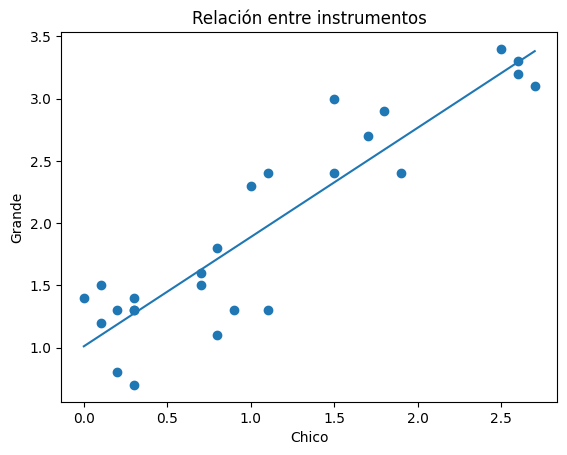

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Variables
x = df["1 (chico)"].values
y = df["2 (grande)"].values

# Linear fit
a, b = np.polyfit(x, y, 1)

# Create line
x_line = np.linspace(min(x), max(x), 100)
y_line = a * x_line + b

# Plot
plt.figure()
plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.xlabel("Chico")
plt.ylabel("Grande")
plt.title("Relación entre instrumentos")
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Reference: chico
X = df[["1 (chico)"]]
y = df["2 (grande)"]

# Fit relation grande = a*chico + b
model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_

# Calibrate grande to chico scale
df["grande_corr"] = (df["2 (grande)"] - b) / a

In [23]:
df

,1 (chico),2 (grande),grande_corr
0,0.1,1.5,0.557509
1,0.3,1.3,0.329841
2,0.3,1.4,0.443675
3,0.2,1.3,0.329841
4,0.1,1.2,0.216007
5,0.0,1.4,0.443675
6,0.2,0.8,-0.239329
7,0.3,0.7,-0.353164
8,0.7,1.6,0.671343
9,0.8,1.8,0.899012


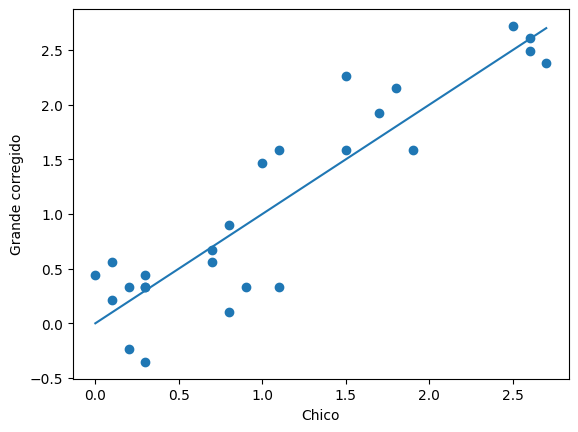

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["1 (chico)"], df["grande_corr"])
plt.plot([0, df["1 (chico)"].max()],
         [0, df["1 (chico)"].max()])
plt.xlabel("Chico")
plt.ylabel("Grande corregido")
plt.show()

In [25]:
mean_chico = df["1 (chico)"].mean()
mean_grande = df["2 (grande)"].mean()

diff_medias = mean_grande - mean_chico

print("Media chico:", round(mean_chico, 3))
print("Media grande:", round(mean_grande, 3))
print("Diferencia de medias:", round(diff_medias, 3))

Media chico: 1.065
Media grande: 1.946
Diferencia de medias: 0.881


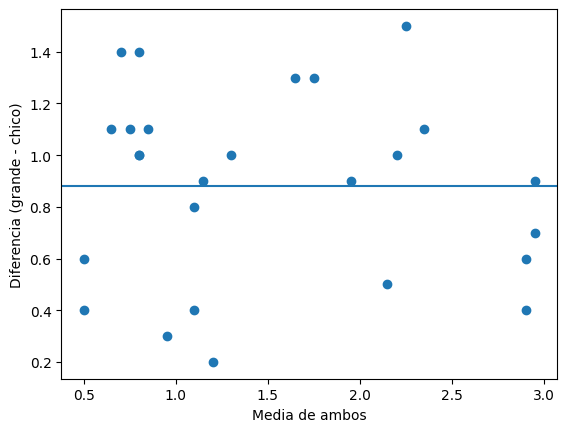

In [27]:
import matplotlib.pyplot as plt

mean_pair = (df["1 (chico)"] + df["2 (grande)"]) / 2

plt.figure()
plt.scatter(mean_pair, df["diff"])
plt.axhline(bias)
plt.xlabel("Media de ambos")
plt.ylabel("Diferencia (grande - chico)")
plt.show()